# Session 1: Technical Basis
## Crash Course with James: Data Storytelling for Darya
This session will cover basic Pandas and Matplotlib functions, as well as give a motivation of what we're looking for in the data. The idea is that we will look at a dataset together, and you will present your own findings about another source of data.
## Prerequisites
Please be sure you have Python installed, as well as Pandas and Matplotlib. Also, choose a small dataset (<20 columns). I'll also put a dataset on the Github for you to download.
## Workflow
The session will cover a basic round of exploratory data science. We will briefly explore the data, clean it, and plot it.
# First task: Load the data and take a first peek!

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
df = pd.read_csv("demand_forecasting.csv") # https://www.kaggle.com/datasets/raminhuseyn/demand-forecasting-dataset
# df_darya = 

In [17]:
df.head()
# df_darya(head)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


# Second task: Check how clean the data are
Use functions like `df.describe()` and see what they tell us. Also, check the sum of missing values with `df.isna()` (extra points if you can get the percent in a nice format, but not necessary). I also find `df.unique_values` helpful.
## Discussion questions:
* Do any variables have different means and medians? Why?
* What do our non-numerical variables tell us?
* How do (would) we approach missing values?
* What do (would) we do with outliers?

Take a few minutes and explore the data set in the cell below (you're always welcome to add a few cells, of course). Also, consider replacing categorical (string) variables with integers. We'll talk about this in the session, but it might be helpful to replace some of them now, so that you can use them in the graphing task.

## Resources:
Missing values: https://www.analyticsvidhya.com/blog/2021/10/handling-missing-value/

Outliers: https://engineergatitu.medium.com/detecting-and-removing-outliers-using-python-1662830b60e5

In [20]:
# check types 
print(df.info())
# descriptive statistics
print(df.describe())
# check missing values
print(df.isna().sum() / df.shape[0] * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

## Quick note
We didn't have time to get into outliers, but a box and whisker plot (boxplot) is a good place to start. However, they're not perfect,
and can produce strange results with skewed data. In general, I worry most about dots that are alone (1 and 3 have them here). I've
also included violin plots to give an idea of the distribution. Personally, I rarely use these in practice. I prefer histograms
and statistical methods. But they're commonly used by others, so I included them here in case you find them intuitive.

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')
~~~ Value counts: Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64
~~~ Value counts: Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64
~~~ Value counts: Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64
~~~ Value counts: Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64
~~~ Value counts: Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64


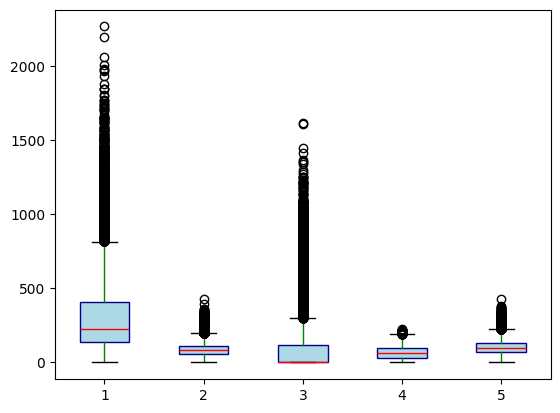

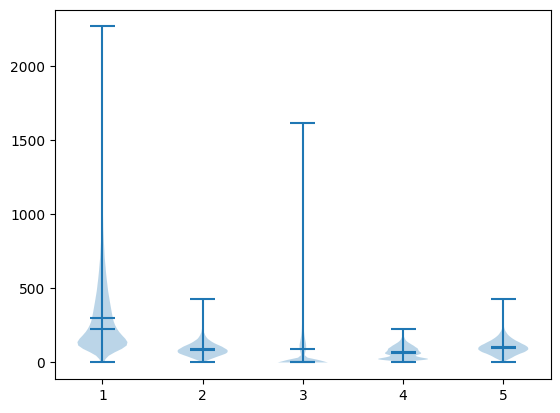

In [21]:
print(df.columns)
# let's check the values for some of the objects (skipping Product ID because it's too many)
for x in ('Store ID', 'Category', 'Region', 'Weather Condition', 'Seasonality'):
    print("~~~ Value counts:", df[x].value_counts())

# a quick check for outliers with boxplots
plt.boxplot(df[['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Demand']], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))
plt.show()

plt.violinplot(df[['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Demand']],
                  showmeans=True,
                  showmedians=True)
plt.show()

# Third Task: Basic Graphing
We have some data, and they're trying to tell us something. As an introduction to data visualization, let's take a minute and produce a few plots. Take a look at the provided cheat sheet and produce (at least) three plots for each data set using: `plt.scatter()`, `plt.bar()`, `plt.hist`

Let's take a minute and dress them up a little. If you can, try to change the following:
* Color
* Axis labels and chart title
* Legend text and placement
* Exchanging different variables in the same graph, to see how things change.

There are tons of examples online. You can spend days playing with it. However, don't burn yourself out, and try to understand the underlying logic of the Matplotlib library. Examples here: https://matplotlib.org/stable/gallery/index.html

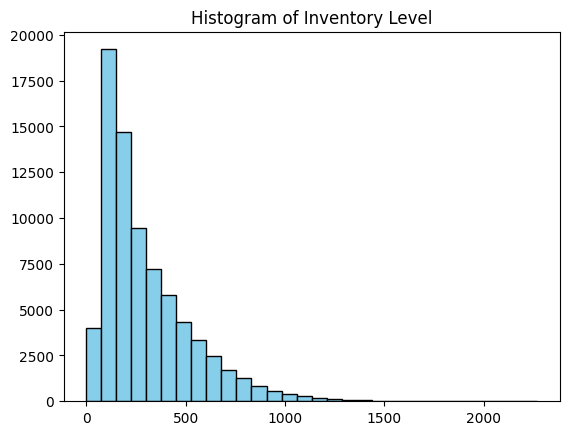

In [11]:
# Histogram
plt.hist('Inventory Level', bins=30, color='skyblue', edgecolor='black', data = df)
plt.title('Histogram of Inventory Level')
plt.show()

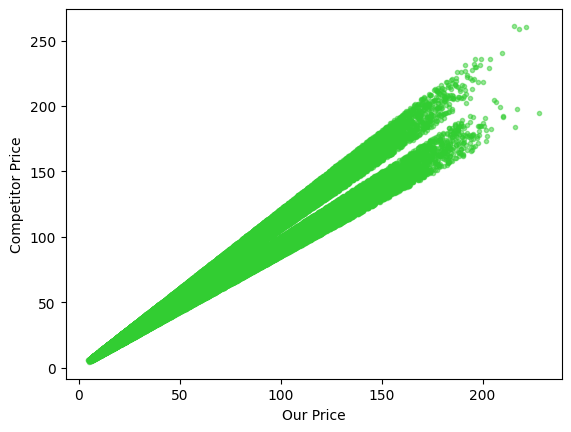

In [6]:
# matplotlib graph
plt.scatter('Price', 
                   'Competitor Pricing', 
                   data=df, 
                   alpha=0.5,
                   marker=".",
                   color='limegreen',
                   label='Price Comparison'
                  )
plt.xlabel('Our Price')
plt.ylabel('Competitor Price')
plt.show()

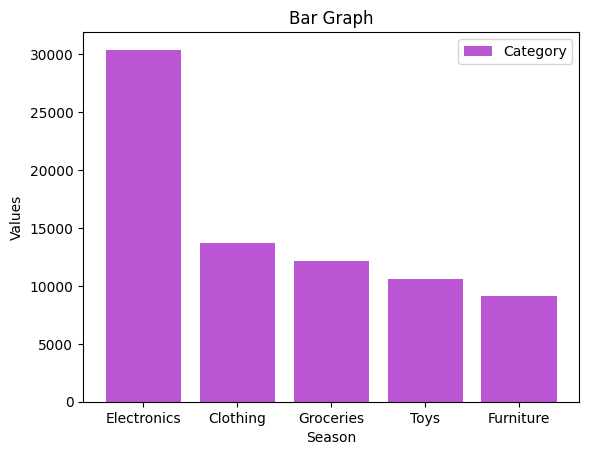

In [14]:
# bar chart 
plt.bar(df['Category'].unique(), height=df['Category'].value_counts(), label='Category', color='mediumorchid')
plt.xlabel('Season')
plt.ylabel('Values')
plt.title('Bar Graph')
plt.legend()
plt.show()


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Electronics'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Groceries'),
  Text(3, 0, 'Toys'),
  Text(4, 0, 'Furniture')])

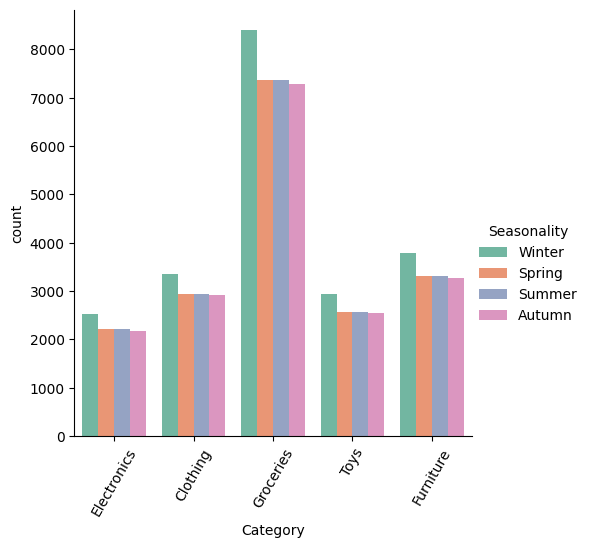

In [16]:
# Bonus chart: from Seaborn!
import seaborn as sns 
sns.catplot(x=df['Category'], kind='count', hue=df['Seasonality'], palette='Set2')
plt.xticks(rotation=60)

# Final Step: Introspection
Congrats! You've completed a basic data science project, from data ingestion and cleaning to presentation! Take a moment and run the previous cell again. Enjoy the feeling of watching your graph appear. You just built that.

Let's think about everything we've done today. In particular, let's reflect on:
* What decisions did we make when we cleaned the data?
* How do the categorical and binary variables affect the dataset?
* What variables worked well for the graphs?
* What graphs did we like? Dislike?
* Do I have any questions for James?